<a href="https://colab.research.google.com/github/rankell05/practical-sql-projects_Relationnel-DataBases/blob/main/Copie_de_task1gee.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [94]:
!pip install earthengine-api

In [8]:
!earthengine authenticate --force

E0000 00:00:1775465126.216646   11474 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775465126.223098   11474 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775465126.238516   11474 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775465126.238548   11474 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775465126.238554   11474 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775465126.238558   11474 computation_placer.cc:177] computation placer already registered. Please check linka

In [67]:
!pip install geemap geopandas

In [91]:
import ee
import geemap
from google.colab import drive

drive.mount('/content/drive')

# Authenticate first
ee.Authenticate()

# Initialize with your Google Cloud project ID
# Go to https://code.earthengine.google.com/ → look at the URL for your project ID
# It looks like "ee-yourname" or "your-pr

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


True

# Visualization of BOUMERDES Region in Algeria

In [92]:
import ee
import geemap

try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

# Load Algeria level-1 boundaries
gaul = ee.FeatureCollection("FAO/GAUL/2015/level1")

# Filter to Algeria first, then Boumerdes
algeria   = gaul.filter(ee.Filter.eq("ADM0_NAME", "Algeria"))
boumerdes = gaul.filter(ee.Filter.eq("ADM0_NAME", "Algeria")) \
                .filter(ee.Filter.eq("ADM1_NAME", "Boumerdes"))  # ← capital B, rest lowercase

# Debug: check it found something
print("Number of features:", boumerdes.size().getInfo())
print("Feature info:", boumerdes.first().getInfo())

Map = geemap.Map()
Map.centerObject(boumerdes, 8)
Map.addLayer(boumerdes, {"color": "red"}, "BOUMERDES")
Map

Number of features: 1
Feature info: {'type': 'Feature', 'geometry': {'type': 'MultiPolygon', 'coordinates': [[[[3.8518874471759807, 36.9123627217805], [3.8525250439783205, 36.91235824344798], [3.8525295477959287, 36.91261245899805], [3.8518918732864487, 36.91261685805644], [3.8518874471759807, 36.9123627217805]]], [[[3.8537245488462046, 36.90515683525501], [3.854527185258869, 36.90540655811051], [3.854081291844303, 36.908492222524245], [3.8537646958988705, 36.90849222324236], [3.853733479038951, 36.90592379784673], [3.8540545787431366, 36.90592373407515], [3.8537245488462046, 36.90515683525501]]], [[[3.2268641523025474, 36.67248983734827], [3.2294013738408296, 36.67018892093005], [3.234208307504825, 36.669676148176144], [3.2383463139745783, 36.6704163263778], [3.240763164000311, 36.66262184468746], [3.243817687976282, 36.66147585742751], [3.2442724424533185, 36.65918388183325], [3.25856392290976, 36.63918483235439], [3.263914846413552, 36.63013281139982], [3.2594200712412276, 36.626463

Map(center=[36.72988624880607, 3.6380175219334827], controls=(WidgetControl(options=['position', 'transparent_…

# Visualization of sentinel2 Imagery for boumerdes (2000, 2010, 2020)

In [93]:
import ee
import geemap

try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

gaul      = ee.FeatureCollection("FAO/GAUL/2015/level1")
boumerdes = gaul.filter(ee.Filter.eq("ADM0_NAME", "Algeria")) \
                .filter(ee.Filter.eq("ADM1_NAME", "Boumerdes"))

# ── Debug: check how many S2 images exist before filtering ──
raw_count = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
             .filterBounds(boumerdes)
             .filterDate("2022-01-01", "2022-12-31")
             .size().getInfo())
print("Total S2 images (no cloud filter):", raw_count)

# ── Relax cloud filter and widen date range ──
s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
      .filterBounds(boumerdes)
      .filterDate("2021-01-01", "2023-12-31")   # wider range
      .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 30))  # relaxed to 30%
      .median()
      .clip(boumerdes))

# ── Check bands exist before selecting ──
print("Raw composite bands:", s2.bandNames().getInfo())

# ── Select only the bands we need ──
bands = s2.select(["B2","B3","B4","B8","B11","B12"])
NDVI  = s2.normalizedDifference(["B8","B4"]).rename("NDVI")
NDBI  = s2.normalizedDifference(["B11","B8"]).rename("NDBI")
NDWI  = s2.normalizedDifference(["B3","B8"]).rename("NDWI")

composite    = bands.addBands([NDVI, NDBI, NDWI])
FEATURE_COLS = ["B2","B3","B4","B8","B11","B12","NDVI","NDBI","NDWI"]

print("Final composite bands:", composite.bandNames().getInfo())

Map = geemap.Map()
Map.centerObject(boumerdes, 10)
Map.addLayer(composite, {"bands":["B4","B3","B2"],"min":0,"max":3000}, "True Colour")
Map.addLayer(NDVI, {"min":-0.2,"max":0.8,"palette":["red","yellow","green"]}, "NDVI")
Map.addLayer(NDBI, {"min":-0.5,"max":0.5,"palette":["white","brown"]},        "NDBI")
Map.addLayer(NDWI, {"min":-0.3,"max":0.5,"palette":["white","blue"]},         "NDWI")
Map

Total S2 images (no cloud filter): 73
Raw composite bands: ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12', 'AOT', 'WVP', 'SCL', 'TCI_R', 'TCI_G', 'TCI_B', 'MSK_CLDPRB', 'MSK_SNWPRB', 'QA10', 'QA20', 'QA60', 'MSK_CLASSI_OPAQUE', 'MSK_CLASSI_CIRRUS', 'MSK_CLASSI_SNOW_ICE']
Final composite bands: ['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'NDBI', 'NDWI']


Map(center=[36.729886248805904, 3.6380175219334143], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
# Cell 8: Noisy labels — export to Drive
import ee
import geemap
import pandas as pd
import time

# ── Step 1: Create binary label from ESA WorldCover ───────────────────────────
worldcover    = ee.ImageCollection("ESA/WorldCover/v200").first().clip(boumerdes)
binary_noisy  = worldcover.eq(50).rename("label").toInt()
stacked_noisy = composite.addBands(binary_noisy)
print("Stacked bands:", stacked_noisy.bandNames().getInfo())

# ── Step 2: Stratified sampling ───────────────────────────────────────────────
N_SAMPLES_PER_CLASS = 300
SAMPLING_SCALE      = 30   # coarser scale = less memory on GEE side

samples_noisy_0 = stacked_noisy.stratifiedSample(
    numPoints   = N_SAMPLES_PER_CLASS,
    classBand   = "label",
    region      = boumerdes.geometry(),
    scale       = SAMPLING_SCALE,
    classValues = [0],
    classPoints = [N_SAMPLES_PER_CLASS],
    seed        = 42,
    geometries  = False
)
samples_noisy_1 = stacked_noisy.stratifiedSample(
    numPoints   = N_SAMPLES_PER_CLASS,
    classBand   = "label",
    region      = boumerdes.geometry(),
    scale       = SAMPLING_SCALE,
    classValues = [1],
    classPoints = [N_SAMPLES_PER_CLASS],
    seed        = 42,
    geometries  = False
)
all_noisy = samples_noisy_0.merge(samples_noisy_1)

# ── Step 3: Export to Drive ───────────────────────────────────────────────────
task_noisy = ee.batch.Export.table.toDrive(
    collection  = all_noisy,
    description = "noisy_labels_boumerdes",
    fileFormat  = "CSV",
    folder      = "GeoAI_Lab"
)
task_noisy.start()
print("Export started...")

while task_noisy.status()["state"] in ["READY", "RUNNING"]:
    print("Waiting... status:", task_noisy.status()["state"])
    time.sleep(15)
print("Final status:", task_noisy.status()["state"])

# ── Step 4: Load from Drive ───────────────────────────────────────────────────
if task_noisy.status()["state"] == "COMPLETED":
    df_noisy = pd.read_csv("/content/drive/MyDrive/GeoAI_Lab/noisy_labels_boumerdes.csv")
    df_noisy["label"] = df_noisy["label"].astype(int)
    print(f"\nTotal noisy samples: {len(df_noisy)}")
    print(f"Class distribution:\n{df_noisy['label'].value_counts()}")
    print(f"Columns: {list(df_noisy.columns)}")
else:
    print("Export failed — check GEE Tasks tab")

In [ ]:
# ── Cell 7: Train SVM, RF, XGBoost, LR on noisy labels ───────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
from sklearn.svm            import SVC
from sklearn.ensemble       import RandomForestClassifier
from sklearn.linear_model   import LogisticRegression
from xgboost                import XGBClassifier

X_noisy = df_noisy[FEATURE_COLS].values
y_noisy = df_noisy["label"].values

X_tr_n, X_te_n, y_tr_n, y_te_n = train_test_split(
    X_noisy, y_noisy, test_size=0.3, random_state=42, stratify=y_noisy)

scaler_n = StandardScaler()
X_tr_n_sc = scaler_n.fit_transform(X_tr_n)
X_te_n_sc = scaler_n.transform(X_te_n)

models_noisy = {
    "LR" : LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "RF" : RandomForestClassifier(n_estimators=100, random_state=42),
    "XGB": XGBClassifier(n_estimators=100, use_label_encoder=False,
                         eval_metric="logloss", random_state=42),
}

preds_noisy = {}
for name, model in models_noisy.items():
    model.fit(X_tr_n_sc, y_tr_n)
    preds_noisy[name] = model.predict(X_te_n_sc)
    print(f"{name} trained ✓")

In [ ]:
# Cell 9: Metrics for Track 1 — Noisy Labels
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

results_noisy = {}
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Track 1 — Confusion Matrices (Noisy Labels)", fontsize=13)

for ax, (name, pred) in zip(axes, preds_noisy.items()):
    acc = accuracy_score(y_te_n, pred)
    f1  = f1_score(y_te_n, pred, zero_division=0)
    results_noisy[name] = {"Accuracy": round(acc,4), "F1": round(f1,4)}
    cm  = confusion_matrix(y_te_n, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Non-built","Built-up"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nAcc={acc:.3f}  F1={f1:.3f}", fontsize=10)

plt.tight_layout()
plt.savefig("/content/track1_confusion_matrices.png", dpi=150)
plt.show()
print(pd.DataFrame(results_noisy).T)

In [ ]:
# Cell 10: Clean labels — export to Drive
import ee
import geemap
import pandas as pd
import time

# ── Step 1: Define thresholds + label image ───────────────────────────────────
built_up_clean  = (NDBI.gt(0.0).And(NDVI.lt(0.3)).And(NDWI.lt(0.1)))
non_built_clean = (NDVI.gt(0.2).Or(NDBI.lt(-0.05)))

binary_clean = (ee.Image(1)
                .where(non_built_clean, ee.Image(0))
                .where(built_up_clean,  ee.Image(1))
                .rename("label")
                .toInt()
                .clip(boumerdes))

stacked_clean = composite.addBands(binary_clean)
print("Stacked bands:", stacked_clean.bandNames().getInfo())

# ── Step 2: Stratified sampling ───────────────────────────────────────────────
N_SAMPLES_PER_CLASS = 300
SAMPLING_SCALE      = 30

samples_clean_0 = stacked_clean.stratifiedSample(
    numPoints   = N_SAMPLES_PER_CLASS,
    classBand   = "label",
    region      = boumerdes.geometry(),
    scale       = SAMPLING_SCALE,
    classValues = [0],
    classPoints = [N_SAMPLES_PER_CLASS],
    seed        = 42,
    geometries  = False
)
samples_clean_1 = stacked_clean.stratifiedSample(
    numPoints   = N_SAMPLES_PER_CLASS,
    classBand   = "label",
    region      = boumerdes.geometry(),
    scale       = SAMPLING_SCALE,
    classValues = [1],
    classPoints = [N_SAMPLES_PER_CLASS],
    seed        = 42,
    geometries  = False
)
all_clean = samples_clean_0.merge(samples_clean_1)

# ── Step 3: Export to Drive ───────────────────────────────────────────────────
task_clean = ee.batch.Export.table.toDrive(
    collection  = all_clean,
    description = "clean_labels_boumerdes",
    fileFormat  = "CSV",
    folder      = "GeoAI_Lab"
)
task_clean.start()
print("Export started...")

while task_clean.status()["state"] in ["READY", "RUNNING"]:
    print("Waiting... status:", task_clean.status()["state"])
    time.sleep(15)
print("Final status:", task_clean.status()["state"])

# ── Step 4: Load from Drive ───────────────────────────────────────────────────
if task_clean.status()["state"] == "COMPLETED":
    df_clean = pd.read_csv("/content/drive/MyDrive/GeoAI_Lab/clean_labels_boumerdes.csv")
    df_clean["label"] = df_clean["label"].astype(int)
    print(f"\nTotal clean samples: {len(df_clean)}")
    print(f"Class distribution:\n{df_clean['label'].value_counts()}")
    print(f"Columns: {list(df_clean.columns)}")
else:
    print("Export failed — check GEE Tasks tab")

In [ ]:
# Cell 10: Train 4 models on clean labels
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.svm             import SVC
from sklearn.ensemble        import RandomForestClassifier
from sklearn.linear_model    import LogisticRegression
from xgboost                 import XGBClassifier

# Use only columns that exist in df_clean
available_features = [c for c in FEATURE_COLS if c in df_clean.columns]
print("Features used:", available_features)

X_c = df_clean[available_features].values
y_c = df_clean["label"].values

X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_c, y_c, test_size=0.3, random_state=42, stratify=y_c)

scaler_c  = StandardScaler()
X_tr_c_sc = scaler_c.fit_transform(X_tr_c)
X_te_c_sc = scaler_c.transform(X_te_c)

models_clean = {
    "LR" : LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel="rbf", random_state=42),
    "RF" : RandomForestClassifier(n_estimators=100, random_state=42),
    "XGB": XGBClassifier(n_estimators=100, use_label_encoder=False,
                         eval_metric="logloss", random_state=42),
}

preds_clean = {}
for name, model in models_clean.items():
    model.fit(X_tr_c_sc, y_tr_c)
    preds_clean[name] = model.predict(X_te_c_sc)
    print(f"{name} trained ✓")

In [ ]:
# Cell 11: Metrics for Track 2
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

results_clean = {}
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Track 2 — Confusion Matrices (Clean Labels)", fontsize=13)

for ax, (name, pred) in zip(axes, preds_clean.items()):
    acc = accuracy_score(y_te_c, pred)
    f1  = f1_score(y_te_c, pred, zero_division=0)
    results_clean[name] = {"Accuracy": round(acc,4), "F1": round(f1,4)}
    cm  = confusion_matrix(y_te_c, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Non-built","Built-up"]).plot(ax=ax, colorbar=False)
    ax.set_title(f"{name}\nAcc={acc:.3f}  F1={f1:.3f}", fontsize=10)

plt.tight_layout()
plt.savefig("/content/track2_confusion_matrices.png", dpi=150)
plt.show()
print(pd.DataFrame(results_clean).T)

In [ ]:
# ── Cell 12: Track 3 — side-by-side comparison ───────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

df_comp = pd.DataFrame({
    ("Noisy", "Accuracy"): {k: v["Accuracy"] for k,v in results_noisy.items()},
    ("Noisy", "F1"):       {k: v["F1"]       for k,v in results_noisy.items()},
    ("Clean", "Accuracy"): {k: v["Accuracy"] for k,v in results_clean.items()},
    ("Clean", "F1"):       {k: v["F1"]       for k,v in results_clean.items()},
})
print("\n=== Track 3: Noisy vs Clean Comparison ===")
print(df_comp.to_string())

# Bar chart
models_list = list(results_noisy.keys())
x = np.arange(len(models_list))
width = 0.2

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - 1.5*width, [results_noisy[m]["Accuracy"] for m in models_list], width, label="Noisy Acc",  color="#D85A30")
ax.bar(x - 0.5*width, [results_noisy[m]["F1"]       for m in models_list], width, label="Noisy F1",   color="#F09595")
ax.bar(x + 0.5*width, [results_clean[m]["Accuracy"] for m in models_list], width, label="Clean Acc",  color="#1D9E75")
ax.bar(x + 1.5*width, [results_clean[m]["F1"]       for m in models_list], width, label="Clean F1",   color="#9FE1CB")

ax.set_xticks(x)
ax.set_xticklabels(models_list)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Track 3 — Noisy vs Clean labels: Accuracy & F1 per model")
ax.legend()
ax.axhline(0.9, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig("/content/track3_comparison.png", dpi=150)
plt.show()

In [90]:
# Cell 13: Classification map over ROI — export to Drive to avoid memory limit
import numpy as np
import pandas as pd

best_model  = models_clean["RF"]
best_scaler = scaler_c

# ── Step 1: Export sampled pixels to Drive ────────────────────────────────────
map_sample = composite.sample(
    region     = boumerdes.geometry(),
    scale      = 50,
    seed       = 0,
    geometries = True
)

task = ee.batch.Export.table.toDrive(
    collection  = map_sample,
    description = "map_sample_boumerdes",
    fileFormat  = "CSV",
    folder      = "GeoAI_Lab"
)
task.start()
print("Export started...")

# ── Step 2: Wait for export ───────────────────────────────────────────────────
import time
while task.status()["state"] in ["READY", "RUNNING"]:
    print("Waiting... status:", task.status()["state"])
    time.sleep(15)
print("Final status:", task.status()["state"])

# ── Step 3: Load CSV and predict ──────────────────────────────────────────────
if task.status()["state"] == "COMPLETED":
    df_map = pd.read_csv("/content/drive/MyDrive/GeoAI_Lab/map_sample_boumerdes.csv")
    df_map = df_map.dropna(subset=FEATURE_COLS)

    X_map          = best_scaler.transform(df_map[FEATURE_COLS].values)
    df_map["pred"] = best_model.predict(X_map)

    print(f"Total pixels: {len(df_map)}")
    print(f"Built-up predicted: {df_map['pred'].sum()}")
    print(f"Non-built predicted: {(df_map['pred']==0).sum()}")

    # ── Step 4: Display on map ────────────────────────────────────────────────
    df_built    = df_map[df_map["pred"] == 1][["longitude","latitude","pred"]]
    df_nonbuilt = df_map[df_map["pred"] == 0][["longitude","latitude","pred"]]

    fc_built    = geemap.df_to_ee(df_built)
    fc_nonbuilt = geemap.df_to_ee(df_nonbuilt)

    Map6 = geemap.Map()
    Map6.centerObject(boumerdes, 11)
    Map6.addLayer(composite,   {"bands":["B4","B3","B2"],"min":0,"max":3000}, "True Colour")
    Map6.addLayer(fc_nonbuilt, {"color":"green"}, "Non Built-up")
    Map6.addLayer(fc_built,    {"color":"red"},   "Predicted Built-up (RF)")
    Map6.addLayer(boumerdes,   {"color":"black"}, "Boumerdes boundary")
    Map6
else:
    print("Export failed — check GEE Tasks tab")

Export started...
Waiting... status: READY
Waiting... status: RUNNING
Waiting... status: RUNNING
Waiting... status: RUNNING
Waiting... status: RUNNING
Waiting... status: RUNNING
Waiting... status: RUNNING
Waiting... status: RUNNING
Waiting... status: RUNNING
Final status: COMPLETED
Total pixels: 717969
Built-up predicted: 99100
Non-built predicted: 618869


KeyError: "['longitude', 'latitude'] not in index"

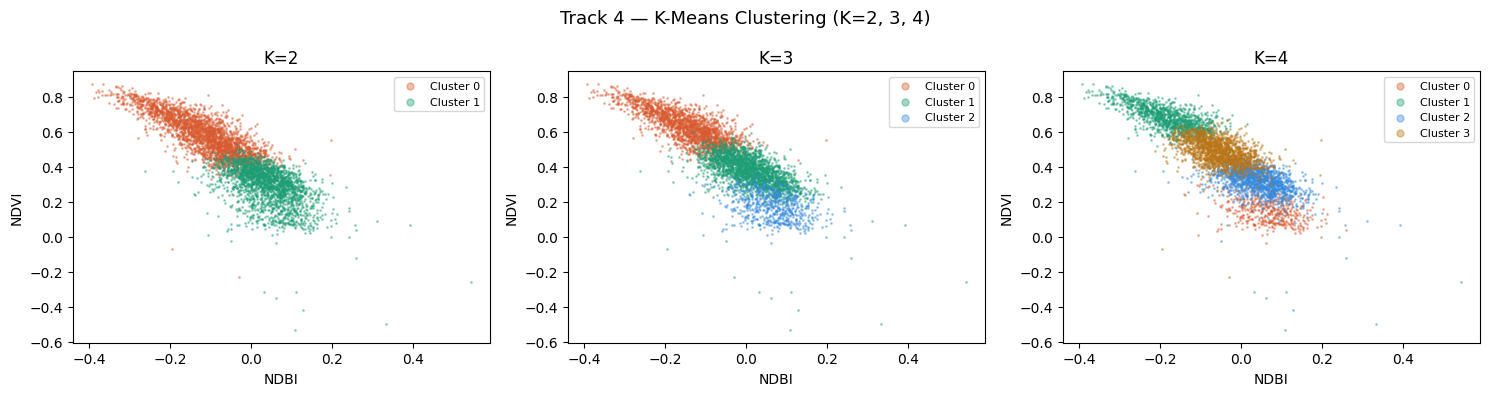

KeyError: "None of [Index(['longitude', 'latitude'], dtype='object')] are in the [columns]"

In [61]:
# ── Cell 14: Unsupervised K-Means clustering ──────────────────────────────────
from sklearn.cluster      import KMeans
from sklearn.preprocessing import StandardScaler

# Reuse df_all (all sampled pixels, no labels)
X_clust = df_all[FEATURE_COLS].dropna().values
scaler_k = StandardScaler()
X_clust_sc = scaler_k.fit_transform(X_clust)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Track 4 — K-Means Clustering (K=2, 3, 4)", fontsize=13)

for ax, k in zip(axes, [2, 3, 4]):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust_sc)

    # Plot using NDBI vs NDVI (most discriminative for urban)
    ndbi_idx = FEATURE_COLS.index("NDBI")
    ndvi_idx = FEATURE_COLS.index("NDVI")
    colors = ["#D85A30","#1D9E75","#378ADD","#BA7517"]

    for c in range(k):
        mask = labels == c
        ax.scatter(X_clust[mask, ndbi_idx], X_clust[mask, ndvi_idx],
                   s=1, alpha=0.4, color=colors[c], label=f"Cluster {c}")

    ax.set_xlabel("NDBI"); ax.set_ylabel("NDVI")
    ax.set_title(f"K={k}")
    ax.legend(markerscale=5, fontsize=8)

plt.tight_layout()
plt.savefig("/content/track4_kmeans_scatter.png", dpi=150)
plt.show()

# Spatial map for K=2 (most interpretable)
km2      = KMeans(n_clusters=2, random_state=42, n_init=10)
df_all_clean = df_all[FEATURE_COLS].dropna().copy()
df_all_clean["cluster"] = km2.fit_predict(scaler_k.transform(df_all_clean.values))
df_all_clean[["longitude","latitude","cluster"]] = df_all[["longitude","latitude"]].join(
    df_all_clean[["cluster"]])

print("\nCluster sizes (K=2):")
print(df_all_clean["cluster"].value_counts())
print("\nCluster means (NDVI / NDBI):")
print(df_all_clean.groupby("cluster")[["NDVI","NDBI"]].mean().round(3))
print("""
Interpretation guide:
  High NDBI + Low NDVI → likely built-up cluster
  Low  NDBI + High NDVI → likely vegetation/non-built cluster
""")